# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [13]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import plotly.figure_factory as ff
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [3]:
X_test = pd.read_csv('X_testt.csv', delimiter=',')
X_train = pd.read_csv('X_train_balancedd.csv', delimiter=',')
y_test = pd.read_csv('y_testt.csv', delimiter=',')
y_train = pd.read_csv('y_train_balancedd.csv', delimiter=',')

In [4]:
X_test

,Age,Income,Number of Children,Gender_encoded,Marital Status_encoded,Home Ownership_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,25,5500000.0,0,0,1,1,1,0,0,0
1,48,8750000.0,1,0,0,0,0,1,0,0
2,26,5500000.0,1,0,0,0,1,0,0,0
3,39,6250000.0,2,0,0,0,1,0,0,0
4,35,9000000.0,1,0,0,0,0,1,0,0
5,25,5500000.0,0,0,1,1,1,0,0,0
6,48,8250000.0,1,0,0,0,0,1,0,0
7,48,8250000.0,1,0,0,0,0,1,0,0
8,36,9500000.0,2,0,0,0,0,0,0,1
9,36,9500000.0,1,0,0,0,0,0,1,0


In [5]:
y_test

,Credit Score
0,0
1,1
2,0
3,1
4,1
5,0
6,1
7,1
8,1
9,1


In [6]:
y_train

,Credit Score
0,0
1,2
2,0
3,0
4,0
...,...
247,2
248,2
249,2
250,2


In [7]:
X_train

,Age,Income,Number of Children,Gender_encoded,Marital Status_encoded,Home Ownership_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,26,4.500000e+06,0,0,1,1,0,0,0,0
1,29,2.750000e+06,0,0,1,1,0,0,1,0
2,25,6.250000e+06,0,0,1,1,1,0,0,0
3,29,6.800000e+06,2,0,0,0,0,1,0,0
4,31,6.500000e+06,0,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
247,27,3.680365e+06,0,0,1,1,0,0,0,0
248,27,3.750000e+06,0,0,1,1,0,0,1,0
249,28,2.994626e+06,0,0,1,1,0,0,0,0
250,27,3.541294e+06,0,0,1,1,0,0,0,0


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

O primeiro passo para a aplicação de um algoritmo é a coleta dos dados, seja atravéz de um link da web, ou de arquivos .xlml e .csv. O segundo passo é a verificação dos tipos de dados da base, fazendo as tranformações necessárias, ex: dados númericos que estão em formato de string precisam ser transformados em inteiros ou float, dependendo do caso. É feita também a verificação de dados nulos, e o quanto estão presentes em nossa base de dados, para assim serem removidos ou substituídos. Verifica-se também se há dados escritos de forma incorreta nas variáveis categóricas. Outro passo importante é a análise univariada nas variáveis do nosso dataframe e se necessário, realiza-se o tratamento dos outliers e retiram-se insights dessa análise. Com os outliers tratados realiza-se a análise bivariada, onde respodemos perguntas atravéz de gráficos, com o intuito de conhecer melhor a base de dados. Em seguida, realiza-se a análise de correlação entre as variáveis, também é feito o tratamento das categorias para tranformalos em valores numéricos. Assim, dividimos os dados em treino e teste, escolhe-se a variável a ser prevista e guardamos em y_train e y_test, as outras variáveis ficam em X_test e X_train, e por fim, é feito o balanceamento dos dados de treino para melhor aprendizado do modelo.

Depois disso, o algoritmo da árvore de decisão é teinado utilizando os dados de treinamento. Após o treinamento, aplicamos o modelo aos dados de teste para gerar previsões. A próxima etapa é a avaliação do modelo, onde analisamos métricas como acurácia, precisão, recall, matriz de confusão e F1-score, verificando se o modelo consegue realizar previsões corretas. Essa etapa é essencial para identificar se o modelo está aprendendo corretamente ou se está sofrendo de overfitting. Para melhorar o modelo, podemos identificar as variáveis com maior importância na arvóre de decisão, para assim reduzir a dimensionalidade dos dados, o que pode levar a um modelo mais simples e eficiente.


# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [8]:
arvore = DecisionTreeClassifier(criterion='gini', random_state=0)
arvore.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [15]:
previsoes = arvore.predict(X_train)

In [17]:
relatorio = classification_report(y_train, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        84
           1       1.00      1.00      1.00        84
           2       1.00      1.00      1.00        84

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00      1.00      1.00       252



In [16]:
conf_matrix = confusion_matrix(y_train, previsoes)

# Definindo  nomes de classes
class_names = ['0', '1', '2']

# Plotando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Predicted labels',
    yaxis_title='True labels',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

Observa-se que no treinamento o modelo acertou 100% das previsões nas categorias de score de crédito.

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [9]:
previsoes = arvore.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)
print("Acurácia:", acuracia)

Acurácia: 0.975609756097561


In [10]:
relatorio = classification_report(y_test, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.97      0.98        29
           2       1.00      1.00      1.00         6

    accuracy                           0.98        41
   macro avg       0.95      0.99      0.97        41
weighted avg       0.98      0.98      0.98        41



In [14]:
conf_matrix = confusion_matrix(y_test, previsoes)

# Definindo  nomes de classes
class_names = ['0', '1', '2']

# Plotando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Predicted labels',
    yaxis_title='True labels',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

Aplicando o modelo aos dados de teste, observa-se que houve somente um erro na classe 0. Assim a precisão da classe 0 ficou de 86%, enquanto que o recall da classe 1 ficou de 97%. Logo, o f1-score da classe 0 ficou de 92%, e da classe 1 ficou de 98%. E por fim, o modelo ficou com uma acurácia geral de 98%.

Comparando o desempenho do modelo entre treino e teste, nota-se que em treino houve 100% de acerto em todas as classes, enquanto que no teste houve uma pequena queda de acertos do modelo, pois ele errou em uma classificação. 

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

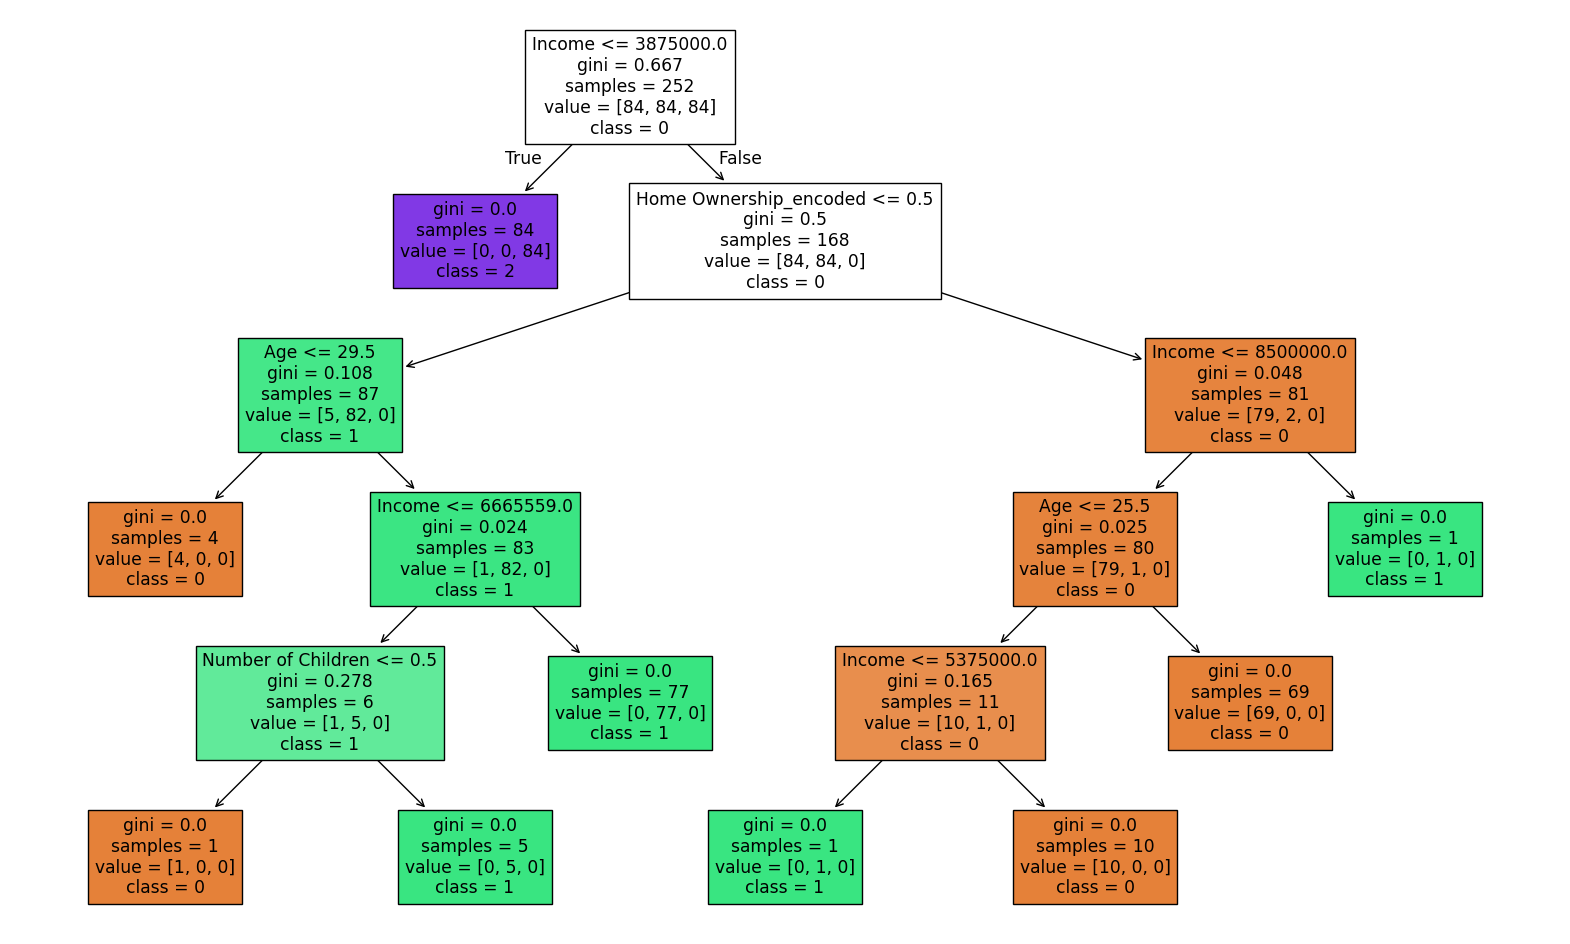

In [14]:
plt.figure(figsize=(20,12))
plot_tree(arvore, filled=True, feature_names=X_train.columns, class_names=['0', '1', '2'])
plt.show()

# 6) Identifique as 2 principais features do modelo.


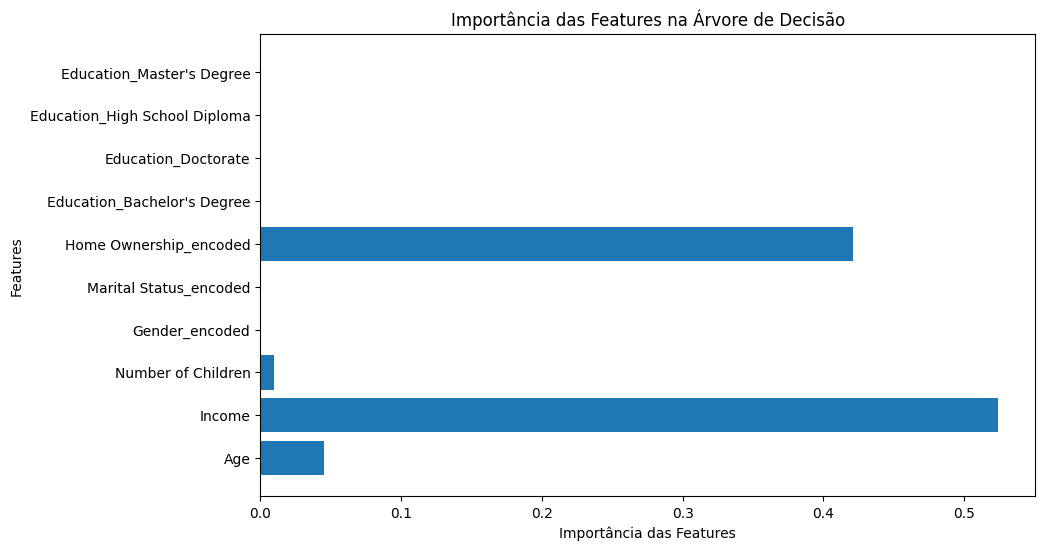

In [ ]:
# Obtendo a importância das características do modelo de árvore de decisão
importancias_features = arvore.feature_importances_

nomes_features = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

As duas principais features são: 'Home Ownership_encoded' e 'Income'.

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [18]:
X_train_reduzido = X_train[['Home Ownership_encoded', 'Income']]
X_test_reduzido = X_test[['Home Ownership_encoded', 'Income']]

In [19]:
arvore_reduzido = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
arvore_reduzido.fit(X_train_reduzido, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [20]:
previsoes_reduzido = arvore_reduzido.predict(X_test_reduzido)

In [21]:
relatorio = classification_report(y_test, previsoes_reduzido)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.97      0.97      0.97        29
           2       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



In [22]:
conf_matrix = confusion_matrix(y_test, previsoes_reduzido)

# Definindo  nomes de classes
class_names = ['0', '1', '2']

# Plotando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Predicted labels',
    yaxis_title='True labels',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

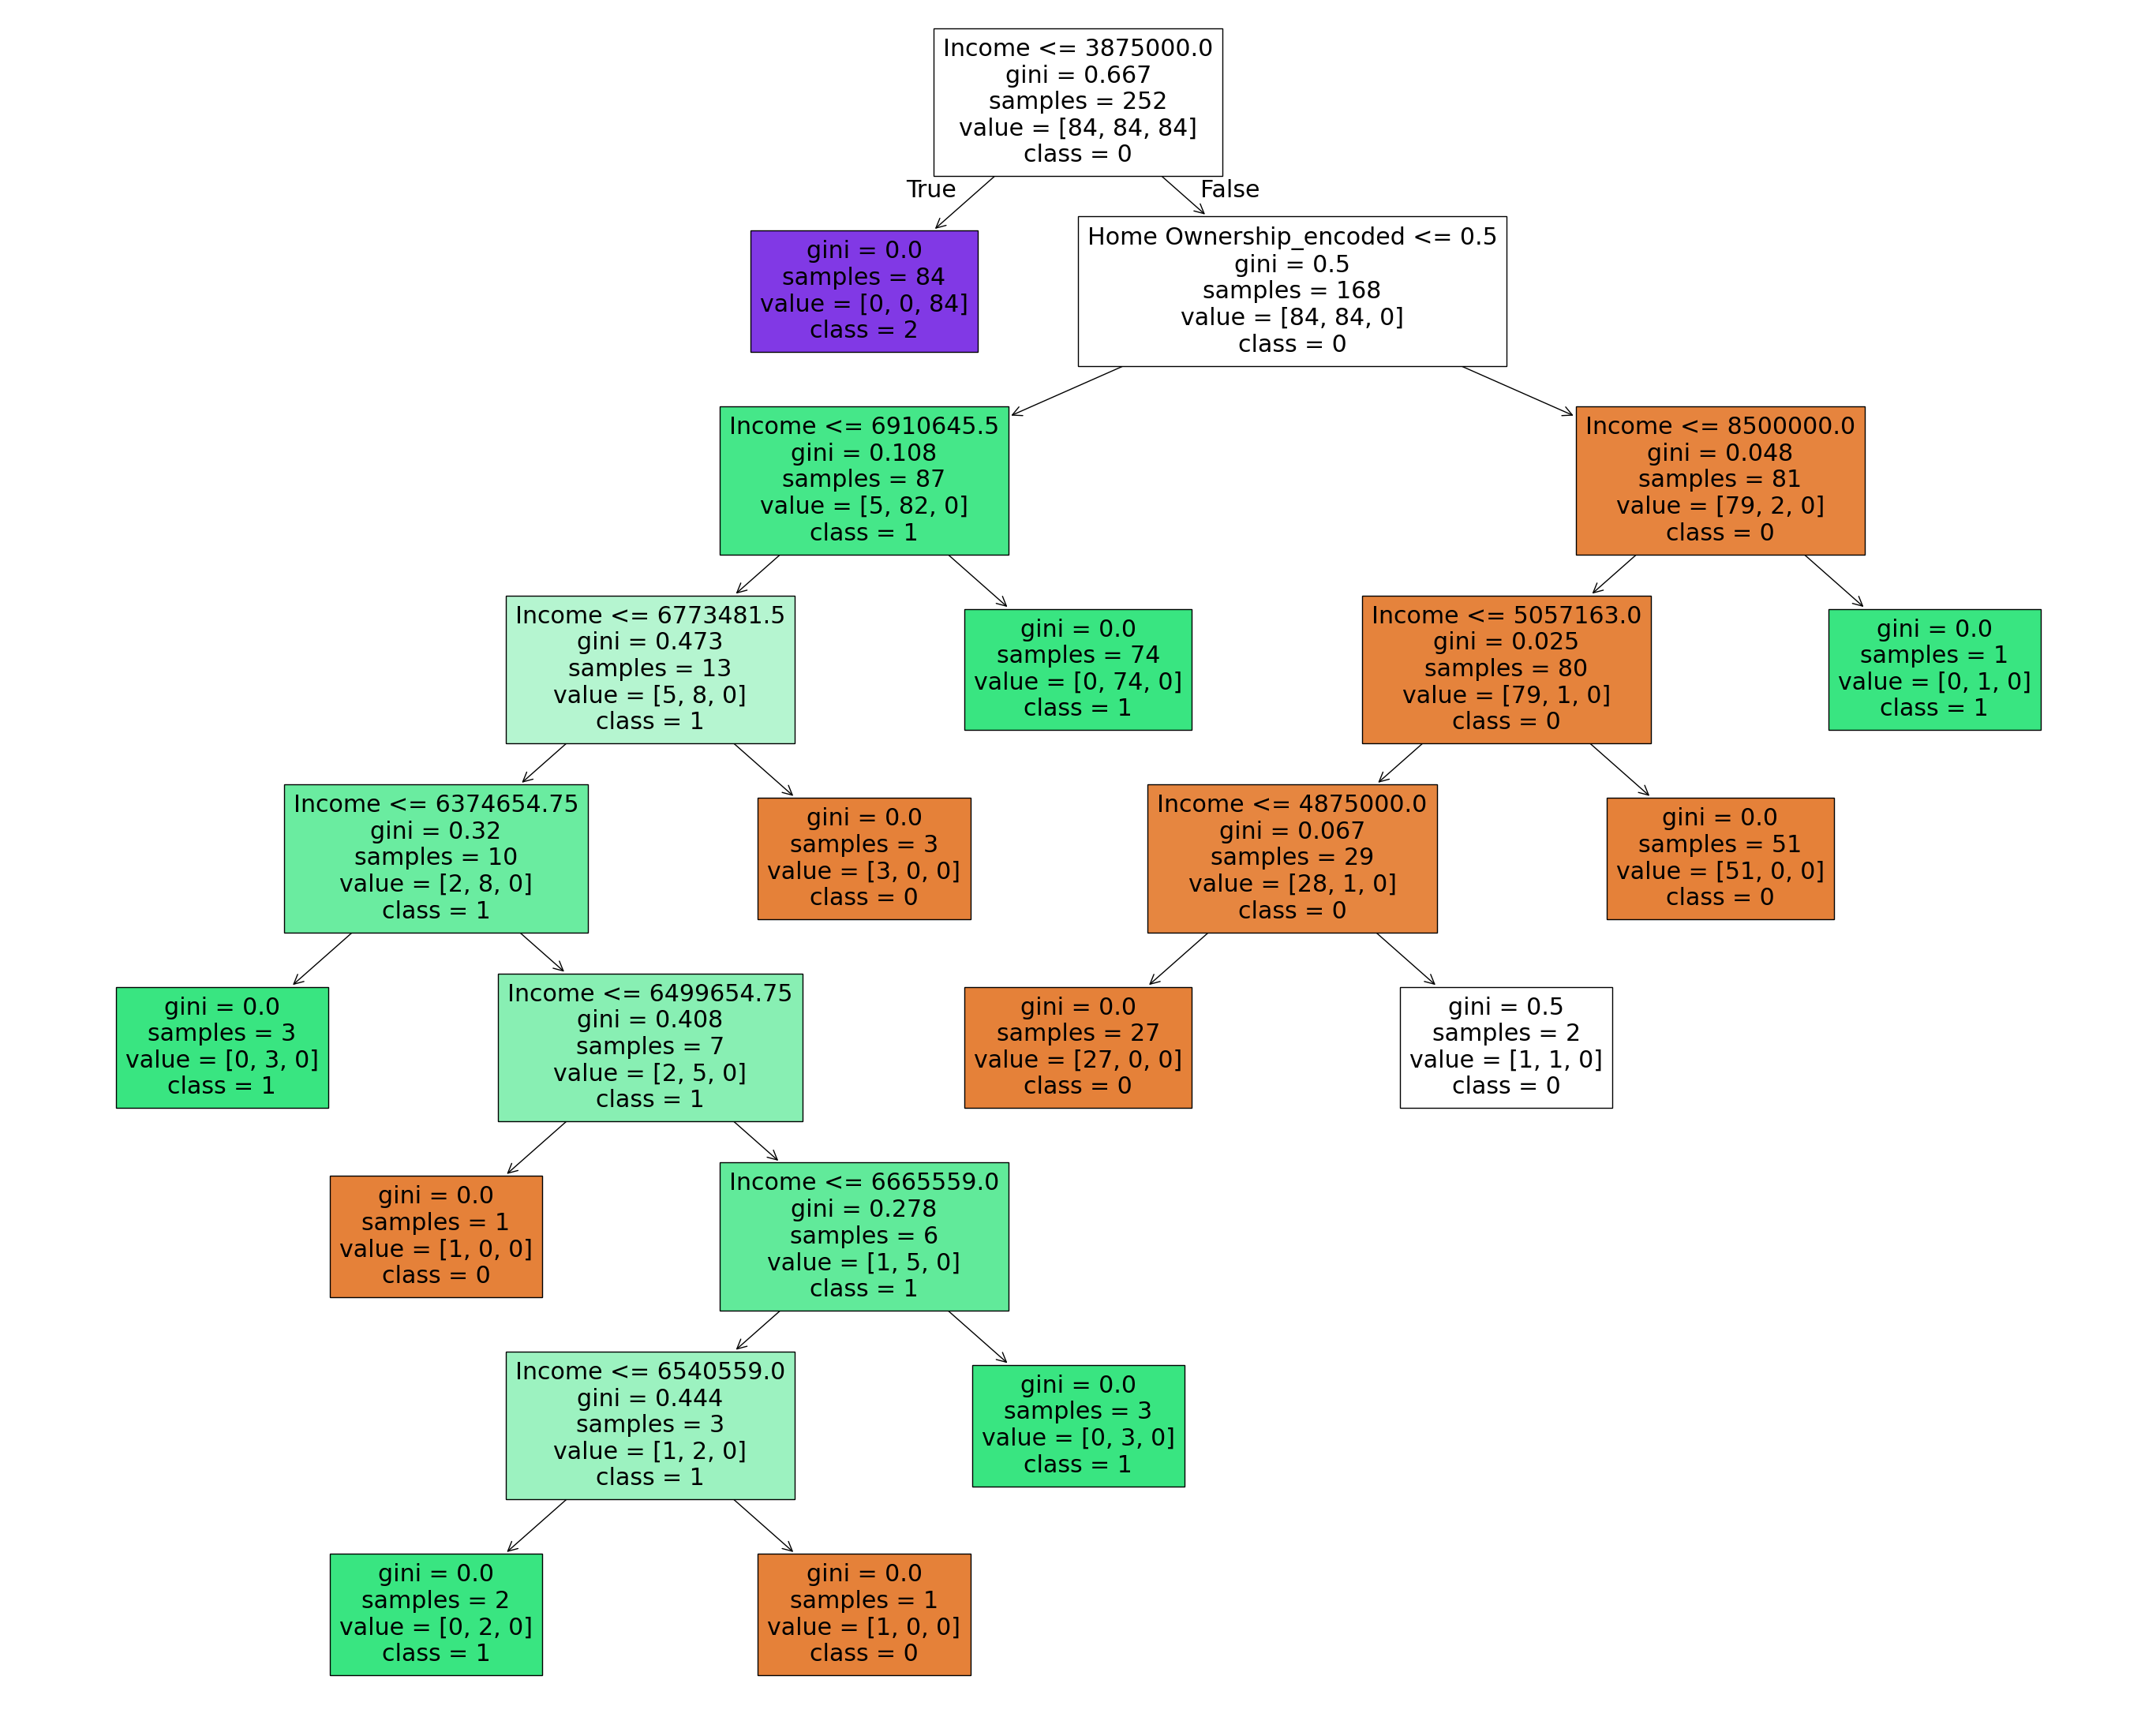

In [23]:
plt.figure(figsize=(35,28))
plot_tree(arvore_reduzido, filled=True, feature_names=X_train_reduzido.columns, class_names=['0', '1', '2'])
plt.show()

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

Naive Bayes:
Acurácia: 92%
Recall: 96%

Árvore de Decisão:
Acurácia: 98%
Recall: 100%

